In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("infection_data.csv")

In [5]:
df.head()

,day,pfemp_variant_frac,infection_id,start_day,duration,total_gametocyte_density,human_id
0,85,0.025234,0,85,165,3284.959044,0
1,52,0.000000,1,52,264,1727.666964,0
2,48,0.000000,2,48,399,3496.682096,0
3,251,0.058879,3,251,206,4173.975590,0
4,323,0.077570,4,323,226,4113.914762,0


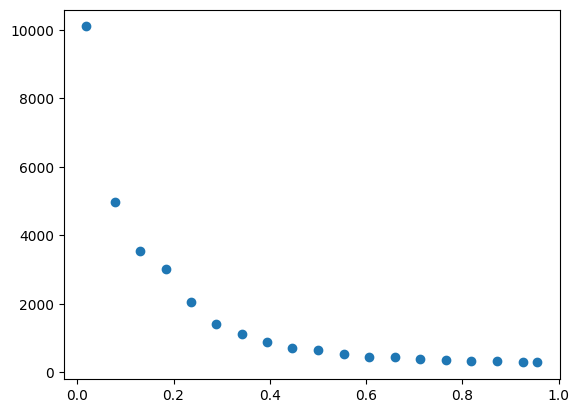

In [13]:
# Bin pfemp_variant_frac into 100 bins and count number of infections in each bin
bins = np.linspace(0, 1, 20)
df['bin'] = np.digitize(df['pfemp_variant_frac'], bins)
df['bin'].value_counts()

# scatter plot bin mean vs number of counts in bin
bin_counts = df['bin'].value_counts()
bin_means = df.groupby('bin')['pfemp_variant_frac'].mean()
plt.scatter(bin_means, bin_counts)

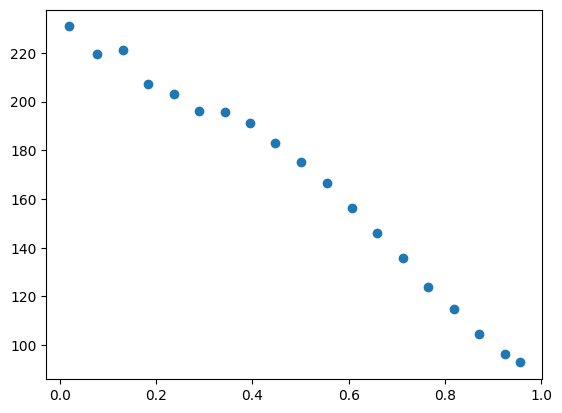

In [14]:
# Get mean duration for all infections in each bin
bin_duration_means = df.groupby('bin')['duration'].mean()
plt.scatter(bin_means, bin_duration_means)

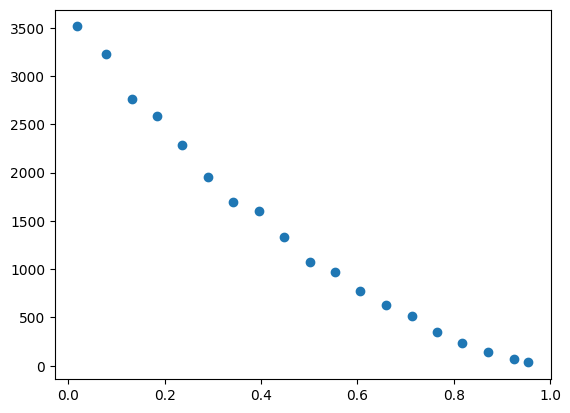

In [15]:
# Get mean total_gametocyte_density for all infections in each bin
bin_tgd_means = df.groupby('bin')['total_gametocyte_density'].mean()
plt.scatter(bin_means, bin_tgd_means)

[-149.12502686] 240.85719560771392


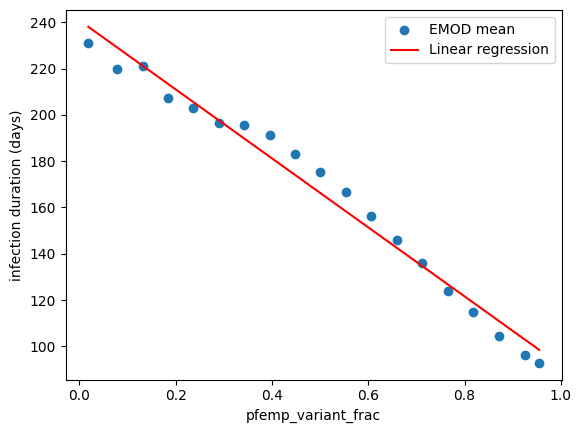

In [29]:
# Fit a linear model to the bin_means vs bin_duration_means
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = bin_means.values.reshape(-1, 1)
y = bin_duration_means.values
model.fit(X, y)
plt.scatter(bin_means, bin_duration_means, label="EMOD mean")
plt.plot(bin_means, model.predict(X), color='red', label="Linear regression")
plt.legend()
plt.xlabel('pfemp_variant_frac')
plt.ylabel('infection duration (days)')

# Print the slope and offset of the model
print(model.coef_, model.intercept_)

# Verify that the model coefficients mean what we think they mean
# plt.plot(bin_means, model.coef_ * bin_means + model.intercept_, color='green', linestyle='dashed')

[    0.         -6409.78868457  2767.16784511] 3635.056354968346


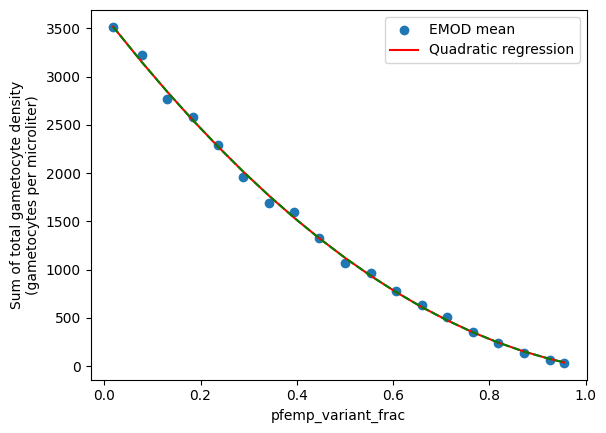

In [36]:
# Fit a quadratic model to the bin_means vs total_gametocyte_density
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X = poly.fit_transform(bin_means.values.reshape(-1, 1))
y = bin_tgd_means.values
model = LinearRegression()
model.fit(X, y)
plt.scatter(bin_means, bin_tgd_means, label="EMOD mean")
plt.plot(bin_means, model.predict(X), color='red', label="Quadratic regression")
plt.legend()
plt.xlabel('pfemp_variant_frac')
plt.ylabel('Sum of total gametocyte density\n(gametocytes per microliter)')

# Print the coefficients of the model
print(model.coef_, model.intercept_)

# Verify that the model coefficients mean what we think they mean
plt.plot(bin_means, model.coef_[2] * bin_means**2 + model.coef_[1] * bin_means + model.intercept_, color='green', linestyle='dashed')

In [38]:
model.coef_[2] * 0.98**2 + model.coef_[1] * 0.98 + model.intercept_

11.051442539283016

In [34]:
240*3500/(100*10)

840.0